### Librerías y Funciones

### Importaciones

In [185]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import os
import numpy as np
import pandas as pd
import random
import time
from collections import Counter
import copy
from IPython.display import display
from PIL import Image

### Funciones Útiles

#### Reproducibilidad

In [140]:
# Fijación de semilla aleatoria para garantizar reproducibilidad
SEMILLA = 31

def fijar_semilla(semilla: int = SEMILLA):
    """
    Fija las semillas aleatorias de Python, NumPy y PyTorch (CPU y GPU/CUDA)
    y configura las banderas de CuDNN para asegurar reproducibilidad determinista.
    """
    random.seed(semilla)
    np.random.seed(semilla)
    torch.manual_seed(semilla)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(semilla)
        torch.cuda.manual_seed_all(semilla)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Inicializamos la semilla global
fijar_semilla(SEMILLA)

# Configuración del dispositivo de cómputo (GPU si está disponible, sino CPU)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo de cómputo seleccionado: {DEVICE}")

Dispositivo de cómputo seleccionado: cpu


#### Selección de Razas

In [141]:
class ImageFolderFiltrado(datasets.ImageFolder):
    def __init__(self, root, transform=None, selected_classes=None):
        self.selected_classes = selected_classes
        super().__init__(root, transform=transform)
        
    def find_classes(self, directory):
        # Obtiene todas las carpetas disponibles
        classes, class_to_idx = super().find_classes(directory)
        
        # Filtra y reasigna índices únicamente para las clases seleccionadas
        if self.selected_classes is not None:
            classes = sorted([c for c in classes if c in self.selected_classes])
            # Genera nuevos índices correlativos del 0 al 9
            class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
            
        return classes, class_to_idx

#### Funciones de Evaluación, Visualización e Inferencia

In [142]:
def evaluar_accuracy_cnn(modelo, loader, device=DEVICE):
    modelo.eval()
    correctos = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = modelo(X_batch)
            preds = logits.argmax(dim=1)

            correctos += (preds == y_batch).sum().item()
            total += X_batch.size(0)

    accuracy = correctos / total if total > 0 else 0
    return f"{accuracy:.2f}"

In [188]:
def evaluar_cnn(modelo, loader, nombre, class_names):
    modelo.eval()
    y_pred = []
    y_true = []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            logits = modelo(X_batch)
            preds = logits.argmax(dim=1)
            y_pred.extend(preds.cpu().numpy())
            y_true.extend(y_batch.cpu().numpy())

    # Matriz de Confusión
    fig, ax = plt.subplots(figsize=(10, 8)) # Tamaño ajustado para mejor visualización
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    
    disp.plot(cmap=plt.cm.Blues, ax=ax, colorbar=False, xticks_rotation='vertical')
    plt.title(f"Matriz de Confusión - {nombre}", fontsize=14, pad=15)
    plt.tight_layout()
    plt.show() 

    # Reporte de Clasificación Estilizado
    report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    df_report = pd.DataFrame(report_dict).transpose()
    df_report['support'] = df_report['support'].astype(int)
    
    # Aplicamos gradiente de color azul a las métricas (excepto al support)
    styled_report = (df_report.style
        .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score'])
        .format({'precision': '{:.2f}', 'recall': '{:.2f}', 'f1-score': '{:.2f}'})
        .set_caption(f"Reporte de Clasificación")
        .set_table_styles([{
            'selector': 'caption',
            'props': [('font-size', '16px'), ('font-weight', 'bold'), ('margin-bottom', '10px')]
        }, {
            'selector': 'th',
            'props': [('text-align', 'center')]
        }])
    )
    
    # Mostramos la tabla renderizada
    display(styled_report)


In [183]:
def graficar_curvas(historial, titulo="Curvas de Entrenamiento"):
    """
    Plotea las curvas de Loss, Accuracy y Learning Rate a partir del historial de entrenamiento.
    Marca la mejor época según el menor valor de val_loss.
    """
    train_loss = historial['train_loss']
    val_loss = historial['val_loss']
    train_acc = historial['train_acc']
    val_acc = historial['val_acc']
    lr = historial.get('lr', None)  # Usamos get por si algún historial no tiene el LR guardado
    
    epocas = range(1, len(train_loss) + 1)
    
    # Identificar la mejor época (mínima pérdida de validación)
    mejor_epoca = val_loss.index(min(val_loss)) + 1
    
    # Determinar columnas: 3 si hay historial de LR, sino 2
    ncols = 3 if lr is not None else 2
    fig, axes = plt.subplots(1, ncols, figsize=(6 * ncols, 5))
    fig.suptitle(titulo, fontsize=16, fontweight='bold')
    
    # Evolución de la Pérdida (Loss)
    axes[0].plot(epocas, train_loss, 'b-', label='Entrenamiento', linewidth=2)
    axes[0].plot(epocas, val_loss, 'r-', label='Validación', linewidth=2)
    axes[0].axvline(x=mejor_epoca, color='green', linestyle='--', label=f'Mejor Época ({mejor_epoca})')
    axes[0].set_title('Evolución de la Pérdida (Loss)', fontsize=14)
    axes[0].set_xlabel('Época', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].legend(fontsize=12)
    axes[0].grid(True, linestyle='--', alpha=0.7)
    
    # Evolución de la Precisión (Accuracy)
    axes[1].plot(epocas, train_acc, 'b-', label='Entrenamiento', linewidth=2)
    axes[1].plot(epocas, val_acc, 'r-', label='Validación', linewidth=2)
    axes[1].axvline(x=mejor_epoca, color='green', linestyle='--', label=f'Mejor Época ({mejor_epoca})')
    axes[1].set_title('Evolución de la Precisión (Accuracy)', fontsize=14)
    axes[1].set_xlabel('Época', fontsize=12)
    axes[1].set_ylabel('Accuracy (%)', fontsize=12)
    axes[1].legend(fontsize=12)
    axes[1].grid(True, linestyle='--', alpha=0.7)
    
    # Evolución del Learning Rate (solo si existe en el historial)
    if lr is not None:
        axes[2].plot(epocas, lr, 'g-', label='Learning Rate', linewidth=2)
        axes[2].axvline(x=mejor_epoca, color='red', linestyle='--', label=f'Mejor Época ({mejor_epoca})')
        axes[2].set_title('Evolución de Tasa de Aprendizaje', fontsize=14)
        axes[2].set_xlabel('Época', fontsize=12)
        axes[2].set_ylabel('Learning Rate', fontsize=12)
        axes[2].set_yscale('log')  # Escala logarítmica es mejor para visualizar LR
        axes[2].legend(fontsize=12)
        axes[2].grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()


In [145]:
def graficar_etiquetado_incorrecto(modelo, loader, class_names, device, cantidad=5):
    """
    Busca imágenes donde el modelo confunde a las razas y las grafica
    """
    modelo.eval()
    errores_encontrados = 0
    
    fig, axes = plt.subplots(1, cantidad, figsize=(15, 4))
    fig.suptitle('Ejemplos de Clasificaciones Incorrectas', fontsize=16, fontweight='bold')
    
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            # Hacemos las predicciones
            logits = modelo(X_batch)
            preds = logits.argmax(dim=1)
            
            # Comparamos cuales son distintas
            son_distintas = (preds != y_batch)
            
            # Filtramos erroneas
            X_errores = X_batch[son_distintas]
            y_errores = y_batch[son_distintas]
            preds_errores = preds[son_distintas]
            
            # Recorremos los errores de este batch
            for i in range(len(X_errores)):
                if errores_encontrados >= cantidad:
                    break # Ya tenemos la cantidad que pedimos
                
                img = X_errores[i].numpy()
                
                # Des-normalizar la imagen para recuperar colores reales
                # (Revertimos el Normalize: img = img * std + mean)
                mean = np.array([0.485, 0.456, 0.406]).reshape(3, 1, 1)
                std = np.array([0.229, 0.224, 0.225]).reshape(3, 1, 1)
                img = img * std + mean
                img = np.clip(img, 0, 1) # Aseguramos que los valores queden entre 0 y 1
                
                # Transponer de (Canal, Alto, Ancho) a (Alto, Ancho, Canal) para Matplotlib
                img = np.transpose(img, (1, 2, 0))
                
                raza_real = class_names[y_errores[i].item()]
                raza_predicha = class_names[preds_errores[i].item()]

                ax = axes[errores_encontrados]
                ax.imshow(img)
                ax.set_title(f"Real: {raza_real}\nPred: {raza_predicha}", 
                             color='red', fontsize=10)
                ax.axis('off')
                
                errores_encontrados += 1
                                
    plt.tight_layout()
    plt.show()

In [146]:
def graficar_etiquetado_correcto(modelo, loader, class_names, device, cantidad=5):
    """
    Busca imágenes donde el modelo aciertas las predicciones de raza y las grafica
    """
    modelo.eval()
    aciertos_encontrados = 0
    
    fig, axes = plt.subplots(1, cantidad, figsize=(15, 4))
    fig.suptitle('Ejemplos de Clasificaciones Correctas', fontsize=16, fontweight='bold')
    
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            # Hacemos las predicciones
            logits = modelo(X_batch)
            preds = logits.argmax(dim=1)
            
            # Comparamos cuales son iguales
            son_iguales = (preds == y_batch)
            
            # Filtramos aciertos
            X_aciertos = X_batch[son_iguales]
            y_aciertos = y_batch[son_iguales]
            preds_aciertos = preds[son_iguales]
            
            # Recorremos los aciertos de este batch
            for i in range(len(X_aciertos)):
                if aciertos_encontrados >= cantidad:
                    break # Ya tenemos la cantidad que pedimos
                
                img = X_aciertos[i].numpy()
                
                # Des-normalizar la imagen para recuperar colores reales
                # (Revertimos el Normalize: img = img * std + mean)
                mean = np.array([0.485, 0.456, 0.406]).reshape(3, 1, 1)
                std = np.array([0.229, 0.224, 0.225]).reshape(3, 1, 1)
                img = img * std + mean
                img = np.clip(img, 0, 1) # Aseguramos que los valores queden entre 0 y 1
                
                # Transponer de (Canal, Alto, Ancho) a (Alto, Ancho, Canal) para Matplotlib
                img = np.transpose(img, (1, 2, 0))
                
                raza_real = class_names[y_aciertos[i].item()]
                raza_predicha = class_names[preds_aciertos[i].item()]

                ax = axes[aciertos_encontrados]
                ax.imshow(img)
                ax.set_title(f"Real: {raza_real}\nPred: {raza_predicha}", 
                             color='green', fontsize=10)
                ax.axis('off')
                
                aciertos_encontrados += 1
                                
    plt.tight_layout()
    plt.show()

## EDA

### Selección de Razas

Para poder ver las fortalezas y falencias del modelo, decidimos seleccionar razas específicas que poseen características morfológicas fácilmente reconocibles como son los 'Pug' y verificar si el modelo es capaz de diferenciar entre razas similares como 'Bulldog' en este caso.

Las razas 'Cockapoo', 'Labradoodle' y 'Poodle' tiene texturas en el pelaje similares, colores variados y morfología similar. De la misma manera encontramos similitudes entre 'Doberman' y 'Rottweiler' o 'Dingo' y 'Coyote' siendo 'Beagle' la única diferente al resto de las razas seleccionadas.

In [147]:

razas_elegidas = ['Beagle', 'Pug', 'Doberman', 
    'Cockapoo', 'Poodle','Coyote','Dingo',
    'Bulldog','Rottweiler','Labradoodle'
]

### Preprocesamiento del Dataset

Previo al análisis de la distribución de clases, se establece el pipeline de carga y preparación de los datos. Para ello se implementa la clase ImageFolderFiltrado, que mapea la estructura de carpetas a etiquetas numéricas conservando únicamente las diez razas seleccionadas. Mediante su argumento de transformación se estandarizan todas las imágenes a dimensiones de 3×224×224 píxeles y se normalizan sus canales RGB con la media y desviación estándar de ImageNet, garantizando consistencia dimensional y numérica en las entradas del modelo.

A partir de estas muestras se construyen los objetos DataLoader utilizando un tamaño de lote de 32, seleccionado para equilibrar la estabilidad de los gradientes con las capacidades de cómputo del entorno local. En la partición de entrenamiento se activa la mezcla aleatoria (shuffle), lo que asegura que las imágenes se reordenen al inicio de cada época para evitar que la red incorpore sesgos vinculados a la secuencia de aparición de las clases y favorecer una convergencia más robusta.


In [148]:
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [149]:
data_dir = './dataset_ej3/' 
print(f"Carpeta contenedora del dataset: {data_dir}")
train_dataset = ImageFolderFiltrado(
    root=os.path.join(data_dir, 'train'), 
    transform=preprocess, 
    selected_classes=razas_elegidas
)
valid_dataset = ImageFolderFiltrado(
    root=os.path.join(data_dir, 'valid'), 
    transform=preprocess, 
    selected_classes=razas_elegidas
)
test_dataset = ImageFolderFiltrado(
    root=os.path.join(data_dir, 'test'), 
    transform=preprocess, 
    selected_classes=razas_elegidas
)

Carpeta contenedora del dataset: ./dataset_ej3/


In [150]:
#Creación de los DataLoaders
batch_size = 32
train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True, 
    num_workers=0, 
    pin_memory=torch.cuda.is_available()
)
valid_loader = DataLoader(
    valid_dataset, 
    batch_size=batch_size, 
    shuffle=False, 
    num_workers=0, 
    pin_memory=torch.cuda.is_available()
)
test_loader  = DataLoader(
    test_dataset, 
    batch_size=batch_size, 
    shuffle=False, 
    num_workers=0, 
    pin_memory=torch.cuda.is_available()
)

In [151]:
# Verificaciones
print(f"Total de clases detectadas: {len(train_dataset.classes)}")
print(f"Índices: {train_dataset.class_to_idx}")
print(f"Total de imágenes para entrenar: {len(train_dataset)}")
print(f"Total de imágenes para validar:  {len(valid_dataset)}")
print(f"Total de imágenes para test:     {len(test_dataset)}")

Total de clases detectadas: 10
Índices: {'Beagle': 0, 'Bulldog': 1, 'Cockapoo': 2, 'Coyote': 3, 'Dingo': 4, 'Doberman': 5, 'Labradoodle': 6, 'Poodle': 7, 'Pug': 8, 'Rottweiler': 9}
Total de imágenes para entrenar: 1181
Total de imágenes para validar:  100
Total de imágenes para test:     100


### Análisis Exploratorio

Observamos la distribución de las diez clases seleccionadas mediante un gráfico de barras apilado

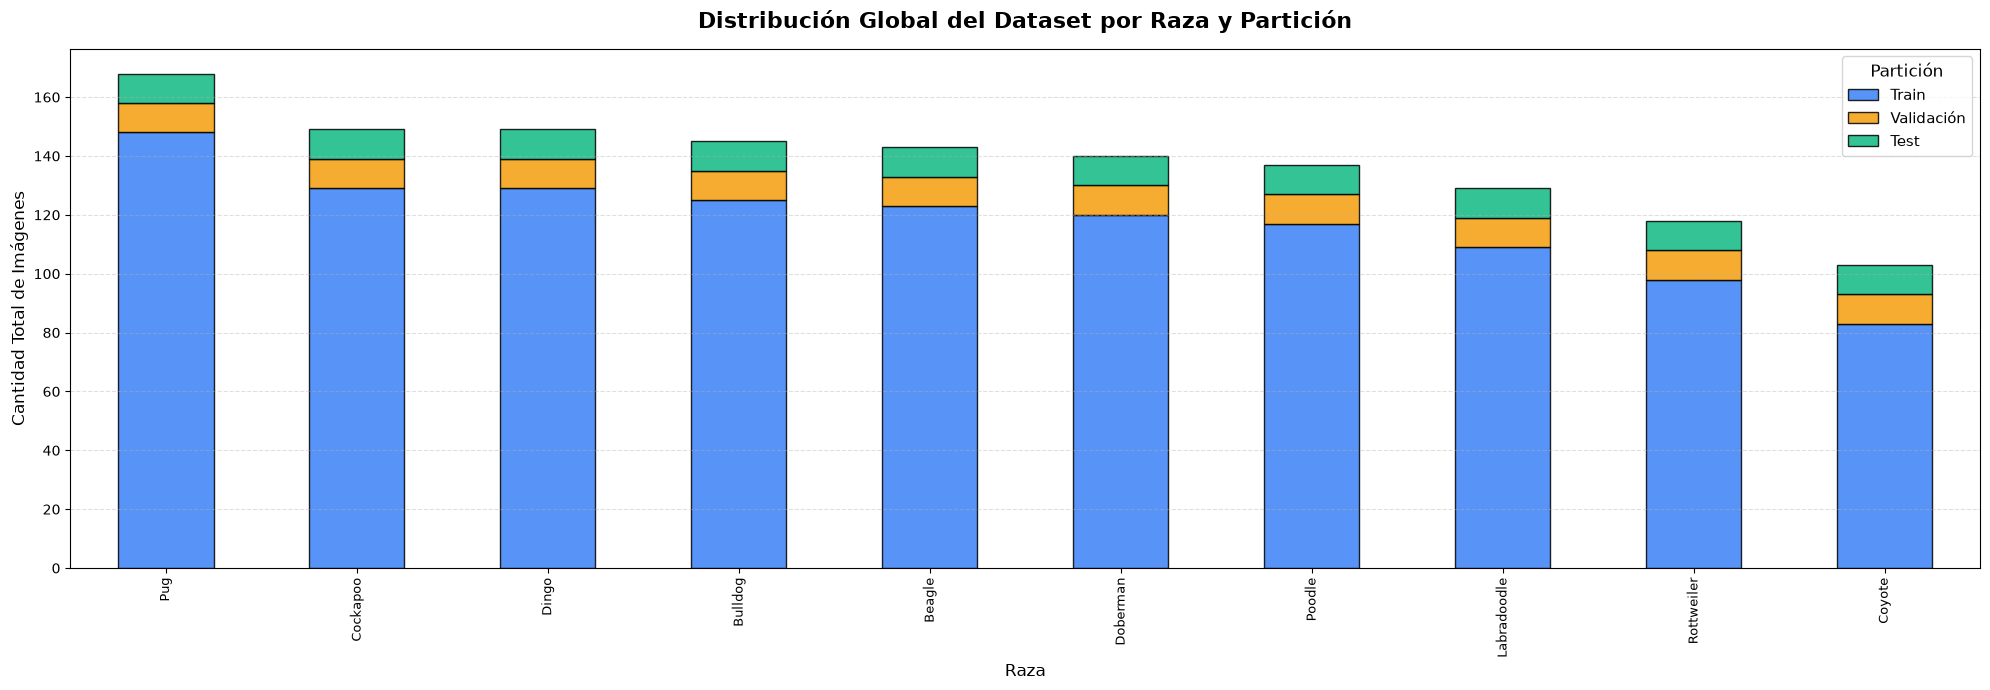

In [152]:
# Creamos el diccionario de mapeo ID -> Nombre de la raza
id_a_raza = {id_num: nombre for nombre, id_num in train_dataset.class_to_idx.items()}

#Contamos las etiquetas de cada partición
conteo_train = Counter(train_dataset.targets)
conteo_val = Counter(valid_dataset.targets)
conteo_test = Counter(test_dataset.targets)

# Consolidamos todo en un DataFrame
df_dist = pd.DataFrame({
    'Train': conteo_train,
    'Validación': conteo_val,
    'Test': conteo_test
    })

# Reemplazamos el índice numérico por los nombres usando nuestro id_a_raza
df_dist.index = [id_a_raza[i] for i in df_dist.index]

# Ordenamos de mayor a menor por total de imágenes
df_dist['Total'] = df_dist.sum(axis=1)
df_dist = df_dist.sort_values(by='Total', ascending=False)
df_dist = df_dist.drop(columns=['Total'])

#Graficamos
colores = ['#3b82f6', '#f59e0b', '#10b981']
plt.figure(figsize=(20, 7))

df_dist.plot(kind='bar', stacked=True, ax=plt.gca(), color=colores, edgecolor='black', alpha=0.85)

plt.title('Distribución Global del Dataset por Raza y Partición', fontsize=16, pad=15, fontweight='bold')
plt.xlabel('Raza', fontsize=12)
plt.ylabel('Cantidad Total de Imágenes', fontsize=12)

plt.xticks(rotation=90, fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend(title='Partición', fontsize=11, title_fontsize=12)

plt.tight_layout()
plt.show()

Mediante este gráfico podemos determinar que existe un desbalance de clases. Esto nos da pie a realizar un proceso de data augmentation para poder mitigar sesgos a la hora de entrenar a nuestros modelos.

## Desarrollo

### Bucle de Entrenamiento Parametrizado

La siguiente función estandariza el ciclo de entrenamiento y evaluación para todas las arquitecturas del trabajo práctico. En cada época, la función alterna entre una fase de optimización con actualización de gradientes sobre el conjunto de entrenamiento y una fase de evaluación sin gradientes sobre el de validación, registrando la evolución de la pérdida y la precisión ponderadas por el tamaño de lote.

Adicionalmente, incorpora el ajuste dinámico de la tasa de aprendizaje y un criterio de parada temprana que interrumpe la ejecución si la pérdida de validación deja de mejorar durante una cantidad determinada de épocas. Al finalizar el ciclo, la función retorna el historial completo de métricas y restaura automáticamente en el modelo los mejores pesos guardados durante el entrenamiento, garantizando que las pruebas posteriores se realicen sobre el punto óptimo de generalización.

In [153]:
def entrenar_modelo(
    modelo: nn.Module,
    loader_train: torch.utils.data.DataLoader,
    loader_val: torch.utils.data.DataLoader,
    criterio: nn.Module,
    optimizador: torch.optim.Optimizer,
    scheduler: torch.optim.lr_scheduler._LRScheduler = None,
    epochs: int = 50,
    patience: int = 10,
    device: torch.device = torch.device('cpu'),
    nombre: str = "Modelo",
    checkpoint_path: str = None,
    reanudar: bool = False  
):
    """
    Bucle de entrenamiento con soporte completo para guardar y reanudar checkpoints.
    """
    es_bce = isinstance(criterio, nn.BCEWithLogitsLoss)

    historial = {
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': []
    }

    epoca_inicial = 1
    mejor_val_loss = float('inf')
    mejor_epoca = 0
    contador_patience = 0

    if reanudar and checkpoint_path is not None and os.path.exists(checkpoint_path):
        print(f" Cargando checkpoint previo desde: '{checkpoint_path}'...")
        checkpoint = torch.load(checkpoint_path, map_location=device)
        
        # Compatibilidad: si el checkpoint anterior solo tenía pesos o el diccionario completo
        if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
            modelo.load_state_dict(checkpoint['model_state_dict'])
            optimizador.load_state_dict(checkpoint['optimizer_state_dict'])
            if scheduler is not None and checkpoint.get('scheduler_state_dict') is not None:
                scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
            epoca_inicial = checkpoint['epoch'] + 1
            mejor_val_loss = checkpoint['val_loss']
            mejor_epoca = checkpoint['epoch']
            historial = checkpoint.get('historial', historial)
            print(f" Checkpoint cargado con éxito. Reanudando desde la época {epoca_inicial} (Mejor Val Loss previo: {mejor_val_loss:.4f}).")
        else:
            # Si solo tenía los pesos directos
            modelo.load_state_dict(checkpoint)
            print(" Se cargaron los pesos del modelo previo (sin estado de optimizador/historial).")
    
    mejor_pesos_memoria = copy.deepcopy(modelo.state_dict())

    print("=" * 80)
    print(f" Iniciando entrenamiento de: {nombre}")
    print(f" Dispositivo: {device} | Épocas: {epoca_inicial} a {epochs} | Patience: {patience}")
    print(f" Criterio: {criterio.__class__.__name__} | Optimizador: {optimizador.__class__.__name__}")
    if scheduler is not None:
        print(f" Scheduler: {scheduler.__class__.__name__}")
    if checkpoint_path is not None:
        print(f" Archivo de Checkpoint: {checkpoint_path}")
    print("=" * 80)

    tiempo_inicio = time.time()

    for epoca in range(epoca_inicial, epochs + 1):
        # ----------------------
        # FASE 1: ENTRENAMIENTO
        # ----------------------
        modelo.train()
        loss_acumulado_train = 0.0
        aciertos_train = 0
        total_train = 0

        for X_batch, y_batch in loader_train:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizador.zero_grad()
            salidas = modelo(X_batch)

            if es_bce:
                y_targets = y_batch.float().view_as(salidas)
                loss = criterio(salidas, y_targets)
                preds = (salidas >= 0.0).long().view_as(y_batch)
            else:
                y_targets = y_batch.long().squeeze()
                loss = criterio(salidas, y_targets)
                preds = salidas.argmax(dim=1)

            loss.backward()
            optimizador.step()

            batch_size_actual = X_batch.size(0)
            loss_acumulado_train += loss.item() * batch_size_actual
            aciertos_train += (preds == y_batch).sum().item()
            total_train += batch_size_actual

        train_loss = loss_acumulado_train / total_train
        train_acc = aciertos_train / total_train

        # ----------------------
        # FASE 2: VALIDACIÓN
        # ----------------------
        modelo.eval()
        loss_acumulado_val = 0.0
        aciertos_val = 0
        total_val = 0

        with torch.no_grad():
            for X_batch, y_batch in loader_val:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                salidas = modelo(X_batch)

                if es_bce:
                    y_targets = y_batch.float().view_as(salidas)
                    loss = criterio(salidas, y_targets)
                    preds = (salidas >= 0.0).long().view_as(y_batch)
                else:
                    y_targets = y_batch.long().squeeze()
                    loss = criterio(salidas, y_targets)
                    preds = salidas.argmax(dim=1)

                batch_size_actual = X_batch.size(0)
                loss_acumulado_val += loss.item() * batch_size_actual
                aciertos_val += (preds == y_batch).sum().item()
                total_val += batch_size_actual

        val_loss = loss_acumulado_val / total_val
        val_acc = aciertos_val / total_val

        historial['train_loss'].append(train_loss)
        historial['val_loss'].append(val_loss)
        historial['train_acc'].append(train_acc)
        historial['val_acc'].append(val_acc)

        # Scheduler
        lr_actual = optimizador.param_groups[0]['lr']
        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()

        # ----------------------
        # FASE 3: GUARDADO COMPLETO DEL CHECKPOINT
        # ----------------------
        mejora_str = ""
        if val_loss < mejor_val_loss:
            mejor_val_loss = val_loss
            mejor_epoca = epoca
            mejor_pesos_memoria = copy.deepcopy(modelo.state_dict())
            contador_patience = 0
            mejora_str = " Guardando nuevo mejor checkpoint"

            if checkpoint_path is not None:
                directorio = os.path.dirname(checkpoint_path)
                if directorio:
                    os.makedirs(directorio, exist_ok=True)
                
                # Guardamos diccionario completo para permitir reanudación exacta
                checkpoint_dict = {
                    'epoch': epoca,
                    'model_state_dict': modelo.state_dict(),
                    'optimizer_state_dict': optimizador.state_dict(),
                    'scheduler_state_dict': scheduler.state_dict() if scheduler is not None else None,
                    'val_loss': mejor_val_loss,
                    'historial': historial
                }
                torch.save(checkpoint_dict, checkpoint_path)
        else:
            contador_patience += 1

        print(
            f"Época [{epoca:02d}/{epochs:02d}] "
            f"| Train Loss: {train_loss:.4f} - Acc: {train_acc*100:5.2f}% "
            f"| Val Loss: {val_loss:.4f} - Acc: {val_acc*100:5.2f}% "
            f"| LR: {lr_actual:.2e}{mejora_str}"
        )

        if contador_patience >= patience:
            print("-" * 80)
            print(f" Early Stopping activado en época {epoca}. Sin mejoras en val_loss por {patience} épocas.")
            break

    tiempo_total = time.time() - tiempo_inicio
    print("=" * 80)
    print(f" Entrenamiento finalizado en {tiempo_total/60:.2f} minutos.")
    print(f" Mejor Val Loss alcanzado: {mejor_val_loss:.4f} en época {mejor_epoca}.")

    # ----------------------
    # RESTAURACIÓN FINAL DEL MEJOR MODELO PARA INFERENCIA
    # ----------------------
    if checkpoint_path is not None and os.path.exists(checkpoint_path):
        chk = torch.load(checkpoint_path, map_location=device)
        if isinstance(chk, dict) and 'model_state_dict' in chk:
            modelo.load_state_dict(chk['model_state_dict'])
        else:
            modelo.load_state_dict(chk)
        print(f" Restaurando modelo desde checkpoint en disco: '{checkpoint_path}'...")
    else:
        modelo.load_state_dict(mejor_pesos_memoria)
        print(f" Restaurando pesos óptimos desde memoria (época {mejor_epoca})...")

    print(" Estado del mejor modelo restaurado exitosamente para evaluación.")
    print("=" * 80)

    return historial, modelo



### E1 - Linea Base


La linea base será una CNN simple, con 3 bloques Conv-BN-ReLU-MaxPool y una cabeza clasificadora densa.

#### Implementación de E1

Para la fase inicial se propone una red convolucional simple que actúa como línea base para clasificar las diez razas seleccionadas, prescindiendo de técnicas de regularización que se evaluarán más adelante. La etapa de extracción consta de tres bloques secuenciales compuestos por convoluciones de 3x3, normalización por lotes, activación ReLU y Max Pooling, escalando la profundidad de 3 a 32, 64 y 128 canales mientras la resolución espacial desciende progresivamente desde 224×224 hasta 28×28 píxeles.

A la salida de las convoluciones se aplica una capa de promedio adaptativo de 4×4 que reduce el volumen de características a 2.048 activaciones, limitando la cantidad de parámetros de la etapa densa. La cabeza clasificadora utiliza dos capas lineales con una activación intermedia de 256 dimensiones para proyectar la salida a los 10 logits finales. El modelo se entrena con CrossEntropyLoss, el optimizador Adam a una tasa inicial de 0.001 y un scheduler de tasa de aprendizaje.


In [154]:
class CNN_E1(nn.Module):
    """
    Fase E1 - Línea Base
    Estructura:
      - 3 bloques: Conv2d -> BatchNorm2d -> ReLU -> MaxPool2d
      - Reducción espacial: AdaptiveAvgPool2d((4, 4))
      - Cabeza clasificadora densa: Linear -> ReLU -> Linear
    """
    def __init__(self, num_classes: int = 10, in_channels: int = 3):
        super().__init__()
        # --- Extractor de Características ---
        self.features = nn.Sequential(
            # Bloque 1: 3 -> 32 canales (resolución espacial 224 -> 112)
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # Bloque 2: 32 -> 64 canales (resolución espacial 112 -> 56)
            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # Bloque 3: 64 -> 128 canales (resolución espacial 56 -> 28)
            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        # --- Reducción Espacial ---
        # Fija la salida a (128, 4, 4), es decir 2048 dimensiones al aplanar
        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))
        # --- Cabeza Clasificadora Densa ---
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, num_classes)
        )
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.adaptive_pool(x)
        logits = self.classifier(x)
        return logits


#### Entrenamiento de E1

In [155]:
fijar_semilla(SEMILLA)
num_clases = len(train_dataset.classes)
modelo_e1 = CNN_E1(num_classes=num_clases, in_channels=3).to(DEVICE)

# Conteo de parámetros
total_params = sum(p.numel() for p in modelo_e1.parameters())
trainable_params = sum(p.numel() for p in modelo_e1.parameters() if p.requires_grad)
print(f"Modelo E1 instanciado en: {DEVICE}")
print(f"Total de parámetros: {total_params:,}")
print(f"Parámetros entrenables: {trainable_params:,}\n")

# Configuración básica
criterio_e1 = nn.CrossEntropyLoss()
optimizador_e1 = torch.optim.Adam(modelo_e1.parameters(), lr=1e-3)
scheduler_e1 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizador_e1, mode='min', factor=0.5, patience=3
)

# Entrenamiento de E1
historial_e1, modelo_e1 = entrenar_modelo(
    modelo=modelo_e1,
    loader_train=train_loader,
    loader_val=valid_loader,
    criterio=criterio_e1,
    optimizador=optimizador_e1,
    scheduler=scheduler_e1,
    epochs=100,
    patience=10,
    device=DEVICE,
    nombre="E1 - Línea Base",
    checkpoint_path="checkpoints_ej3/e1_linea_base.pth",
    reanudar=True
)


Modelo E1 instanciado en: cpu
Total de parámetros: 620,586
Parámetros entrenables: 620,586

 Iniciando entrenamiento de: E1 - Línea Base
 Dispositivo: cpu | Épocas: 1 a 100 | Patience: 10
 Criterio: CrossEntropyLoss | Optimizador: Adam
 Scheduler: ReduceLROnPlateau
 Archivo de Checkpoint: checkpoints_ej3/e1_linea_base.pth
Época [01/100] | Train Loss: 1.9807 - Acc: 29.38% | Val Loss: 1.6355 - Acc: 31.00% | LR: 1.00e-03 Guardando nuevo mejor checkpoint
Época [02/100] | Train Loss: 1.5850 - Acc: 44.28% | Val Loss: 1.2825 - Acc: 57.00% | LR: 1.00e-03 Guardando nuevo mejor checkpoint
Época [03/100] | Train Loss: 1.4058 - Acc: 50.72% | Val Loss: 1.2118 - Acc: 59.00% | LR: 1.00e-03 Guardando nuevo mejor checkpoint
Época [04/100] | Train Loss: 1.2506 - Acc: 56.31% | Val Loss: 1.1223 - Acc: 59.00% | LR: 1.00e-03 Guardando nuevo mejor checkpoint
Época [05/100] | Train Loss: 1.1380 - Acc: 61.30% | Val Loss: 0.9813 - Acc: 66.00% | LR: 1.00e-03 Guardando nuevo mejor checkpoint
Época [06/100] | Trai

El entrenamiento de la línea base se extendió a lo largo de 34 épocas con una duración aproximada de 19 minutos, momento en el cual el criterio de parada temprana detuvo el proceso tras diez épocas consecutivas sin reducciones en el error de validación. El mejor compromiso de generalización se alcanzó en la época 24, registrando una pérdida de validación mínima de 0.5176 junto con una precisión del 85.00%, frente a una pérdida de entrenamiento de 0.1278 y una precisión del 97.97%. 

#### Métricas de E1

In [156]:
acc_train_e1 = float(evaluar_accuracy_cnn(modelo_e1, train_loader, DEVICE))
acc_val_e1   = float(evaluar_accuracy_cnn(modelo_e1, valid_loader, DEVICE))
acc_test_e1  = float(evaluar_accuracy_cnn(modelo_e1, test_loader, DEVICE))

print("=" * 60)
print(" RESUMEN DE RENDIMIENTO - E1 (LÍNEA BASE)")
print("=" * 60)
print(f" Precisión en Entrenamiento (Train):  {acc_train_e1 * 100:6.2f}%")
print(f" Precisión en Validación   (Valid):  {acc_val_e1 * 100:6.2f}%")
print(f" Precisión en Test       (Test):   {acc_test_e1 * 100:6.2f}%")
print("=" * 60)


 RESUMEN DE RENDIMIENTO - E1 (LÍNEA BASE)
 Precisión en Entrenamiento (Train):   99.00%
 Precisión en Validación   (Valid):   85.00%
 Precisión en Test       (Test):    67.00%


Los resultados obtenidos en la evaluación de la línea base reflejan el comportamiento esperado para una red convolucional superficial entrenada sin técnicas de regularización. La discrepancia observada entre la precisión alcanzada sobre el conjunto de entrenamiento y los valores obtenidos en validación y test pone en evidencia una tendencia al sobreajuste, donde la red memoriza patrones específicos del conjunto de entrenamiento que no se transfieren con igual consistencia a muestras no vistas. La estabilización temprana de la pérdida de validación y la consecuente activación del criterio de parada temprana confirman que el modelo alcanza rápidamente el límite de su capacidad de generalización bajo esta configuración.

### E2 - Arquitectura Profunda

La arquitectura E2 profundiza la extracción de características mediante seis capas convolucionales distribuidas en cuatro etapas, duplicando la cantidad de convoluciones empleadas en E1. En la primera etapa se reemplaza el filtro inicial de 3x3 por uno de 5x5, ampliando el campo receptivo temprano para capturar estructuras visuales más extensas antes de reducir la resolución a 112×112. La segunda etapa introduce una convolución con paso o stride de 2 en lugar del Max Pooling tradicional, permitiendo que la red aprenda la reducción espacial a 56×56 mientras escala de 32 a 64 canales, complementada por una segunda convolución de 3x3 que añade profundidad a la etapa.

Las etapas posteriores profundizan la jerarquía visual apilando dos convoluciones de 3x3 que alcanzan los 128 canales y una capa final que escala hasta 256 canales en una resolución de 14x14, superando los 128 canales máximos de E1. A la salida, un promedio adaptativo comprime las activaciones a una matriz de 4x4 por canal, generando 4.096 características aplanadas frente a las 2.048 de la línea base, las cuales alimentan a una cabeza clasificadora de dos capas lineales con 256 dimensiones intermedias para producir los 10 logits finales.

#### Implementación de E2

In [157]:
class CNN_E2(nn.Module):
    """
    Fase E2 - Arquitectura Profunda.
    
    Exploraciones incorporadas respecto a E1:
      1. Mayor profundidad: 6 capas convolucionales (frente a 3 de la línea base).
      2. Filtros de 5x5 en la entrada (mayor campo receptivo inicial) y 3x3 apilados luego.
      3. Variación de strides: stride=2 en la convolución del Bloque 2 (reducción aprendida).
      4. Sin técnicas de regularización.
    """
    def __init__(self, num_classes: int = 10, in_channels: int = 3):
        super().__init__()
        self.features = nn.Sequential(
            # --- ETAPA 1: Filtro 5x5 para amplio campo receptivo inicial ---
            # Entrada: (batch, 3, 224, 224) -> Salida: (batch, 32, 112, 112)
            nn.Conv2d(in_channels, 32, kernel_size=5, stride=1, padding=2, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # --- ETAPA 2: Reducción mediante Convolución con Stride=2 y capas apiladas ---
            # Convolución con stride=2 aprende el submuestreo (112 -> 56) sin MaxPool
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            # Segunda convolución para profundizar la etapa
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            # --- ETAPA 3: Apilado de convoluciones 3x3 con MaxPool ---
            # Entrada: (batch, 64, 56, 56) -> Salida: (batch, 128, 28, 28)
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # --- ETAPA 4: Mayor nivel de abstracción (256 canales) ---
            # Entrada: (batch, 128, 28, 28) -> Salida: (batch, 256, 14, 14)
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        # Reducción espacial fija a (4, 4) -> 256 * 4 * 4 = 4096 características
        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))
        # Cabeza clasificadora densa sin regularización
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, num_classes)
        )
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.adaptive_pool(x)
        logits = self.classifier(x)
        return logits

#### Entrenamiento de E2

In [158]:
fijar_semilla(SEMILLA)
num_clases = len(train_dataset.classes)
modelo_e2 = CNN_E2(num_classes=num_clases, in_channels=3).to(DEVICE)
# Comparativa de parámetros respecto a la línea base
total_params_e2 = sum(p.numel() for p in modelo_e2.parameters())
trainable_params_e2 = sum(p.numel() for p in modelo_e2.parameters() if p.requires_grad)
print(f"Modelo E2 instanciado en: {DEVICE}")
print(f"Total de parámetros E2: {total_params_e2:,}")
print(f"Diferencia respecto a E1: {total_params_e2 - total_params:+,} parámetros\n")
# Configuración de optimización
criterio_e2 = nn.CrossEntropyLoss()
optimizador_e2 = torch.optim.Adam(modelo_e2.parameters(), lr=1e-3)
scheduler_e2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizador_e2, mode='min', factor=0.5, patience=3
)
# Entrenamiento de E2
historial_e2, modelo_e2 = entrenar_modelo(
    modelo=modelo_e2,
    loader_train=train_loader,
    loader_val=valid_loader,
    criterio=criterio_e2,
    optimizador=optimizador_e2,
    scheduler=scheduler_e2,
    epochs=100,
    patience=10,
    device=DEVICE,
    nombre="E2 - Arquitectura Profunda",
    checkpoint_path="checkpoints_ej3/e2_profunda.pth"
)

Modelo E2 instanciado en: cpu
Total de parámetros E2: 1,626,538
Diferencia respecto a E1: +1,005,952 parámetros

 Iniciando entrenamiento de: E2 - Arquitectura Profunda
 Dispositivo: cpu | Épocas: 1 a 100 | Patience: 10
 Criterio: CrossEntropyLoss | Optimizador: Adam
 Scheduler: ReduceLROnPlateau
 Archivo de Checkpoint: checkpoints_ej3/e2_profunda.pth
Época [01/100] | Train Loss: 2.2473 - Acc: 25.06% | Val Loss: 1.7849 - Acc: 31.00% | LR: 1.00e-03 Guardando nuevo mejor checkpoint
Época [02/100] | Train Loss: 1.7613 - Acc: 37.17% | Val Loss: 1.7447 - Acc: 36.00% | LR: 1.00e-03 Guardando nuevo mejor checkpoint
Época [03/100] | Train Loss: 1.5728 - Acc: 44.79% | Val Loss: 1.7033 - Acc: 47.00% | LR: 1.00e-03 Guardando nuevo mejor checkpoint
Época [04/100] | Train Loss: 1.4606 - Acc: 49.20% | Val Loss: 1.2566 - Acc: 63.00% | LR: 1.00e-03 Guardando nuevo mejor checkpoint
Época [05/100] | Train Loss: 1.3134 - Acc: 54.19% | Val Loss: 1.1996 - Acc: 58.00% | LR: 1.00e-03 Guardando nuevo mejor ch

#### Métricas de E2


In [159]:
acc_train_e2 = float(evaluar_accuracy_cnn(modelo_e2, train_loader, DEVICE))
acc_val_e2   = float(evaluar_accuracy_cnn(modelo_e2, valid_loader, DEVICE))
acc_test_e2  = float(evaluar_accuracy_cnn(modelo_e2, test_loader, DEVICE))
print("=" * 60)
print(" RESUMEN DE RENDIMIENTO - E2 (ARQUITECTURA PROFUNDA)")
print("=" * 60)
print(f" Precisión en Train: {acc_train_e2 * 100:6.2f}% (E1: {acc_train_e1 * 100:6.2f}%)")
print(f" Precisión en Valid: {acc_val_e2 * 100:6.2f}% (E1: {acc_val_e1 * 100:6.2f}%)")
print(f" Precisión en Test:  {acc_test_e2 * 100:6.2f}% (E1: {acc_test_e1 * 100:6.2f}%)")
print("=" * 60)

 RESUMEN DE RENDIMIENTO - E2 (ARQUITECTURA PROFUNDA)
 Precisión en Train:  97.00% (E1:  99.00%)
 Precisión en Valid:  79.00% (E1:  85.00%)
 Precisión en Test:   68.00% (E1:  67.00%)


La comparación entre E2 y la línea base E1 muestra que aumentar la profundidad de forma puramente secuencial no mejoró la generalización del modelo. Con 1.626.538 parámetros, E2 sumó más de un millón de parámetros adicionales respecto a E1 y requirió un ~35% más de tiempo de entrenamiento, alcanzando 29.7 minutos. Pese a este mayor costo, la pérdida de validación empeoró de 0.5176 a 0.6358 y la precisión de validación cayó del 85.00% al 79.00%.

En el conjunto de test, la precisión de E2 fue del 68.00%, prácticamente igual al 67.00% de la línea base, lo que en una muestra de 100 imágenes equivale a la diferencia de un solo acierto. Esto confirma que sumar capas sin técnicas adicionales no aportó ventajas frente a un conjunto de datos reducido, dificultando la optimización en lugar de mejorar la capacidad del modelo para generalizar.

### E3 - Bloques Avanzados

#### Clases Auxiliares

##### Implementación de Bloque Residual

El bloque residual facilita el entrenamiento en redes profundas al permitir que los gradientes fluyan sin atenuarse a través de las capas. En lugar de aprender una transformación completa desde cero, el bloque aprende únicamente la diferencia o residuo respecto a la entrada original, sumando directamente la entrada a la salida de las convoluciones. Esto asegura que la red conserve la información previa y aprenda solo correcciones incrementales.

Estructuralmente, la entrada recorre dos caminos que se combinan al final: una rama principal con dos convoluciones de 3x3 y una rama de atajo que pasa la señal directamente. Si la resolución espacial o la cantidad de canales cambian entre la entrada y la salida, el atajo utiliza una convolución simple de 1x1 para igualar las dimensiones antes de la suma, tras la cual se aplica la activación ReLU.



In [160]:
class BloqueResidual(nn.Module):
    """
    Bloque residual básico (estilo ResNet).
    Aprende la función residual F(x) tal que la salida sea H(x) = F(x) + x.
    
    Si stride > 1 o in_channels != out_channels, el camino de atajo (shortcut)
    aplica una convolución 1x1 para proyectar las dimensiones espaciales y de canal.
    """
    def __init__(self, in_channels: int, out_channels: int, stride: int = 1):
        super().__init__()
        # Rama convolucional principal F(x)
        self.conv_branch = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(out_channels)
        )
        # Rama de atajo (shortcut): identidad o proyección lineal 1x1
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
        else:
            self.shortcut = nn.Identity()
        # Activación no lineal final tras la adición elemento a elemento
        self.relu = nn.ReLU(inplace=True)
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        residual = self.conv_branch(x)
        identity = self.shortcut(x)
        return self.relu(residual + identity)


##### Implementación de Módulo Inception

El módulo Inception procesa la información visual a múltiples escalas en simultáneo, evitando tener que fijar un único tamaño de filtro para toda la capa. La misma entrada se envía a cuatro ramas paralelas que aplican convoluciones de 1x1, 3x3, 5x5 y una operación de Max Pooling. Al final, las salidas de todas las ramas se concatenan sobre el eje de canales, permitiendo que la red capture detalles puntuales, texturas intermedias y patrones espaciales más amplios al mismo tiempo.

Para mantener un bajo costo computacional, el módulo utiliza convoluciones de 1x1 como cuellos de botella antes de los filtros más pesados de 3x3 y 5x5. Estas convoluciones reducen temporalmente la cantidad de canales, disminuyendo la cantidad de parámetros y cálculos necesarios sin perder capacidad de representación, para luego reconstruir el volumen final de características.


In [161]:
class ModuloInception(nn.Module):
    """
    Módulo Inception con ramas paralelas multiescala y cuellos de botella 1x1.
    
    Procesa la entrada en cuatro vías simultáneas:
      - Rama 1: Convolución puntual 1x1.
      - Rama 2: Cuello de botella 1x1 seguido de convolución 3x3.
      - Rama 3: Cuello de botella 1x1 seguido de convolución 5x5.
      - Rama 4: MaxPool 3x3 preservando tamaño espacial, seguido de convolución 1x1.
    """
    def __init__(
        self,
        in_channels: int,
        out_1x1: int,
        red_3x3: int,
        out_3x3: int,
        red_5x5: int,
        out_5x5: int,
        out_pool: int
    ):
        super().__init__()
        # Rama 1: Convolución 1x1
        self.rama_1x1 = nn.Sequential(
            nn.Conv2d(in_channels, out_1x1, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_1x1),
            nn.ReLU(inplace=True)
        )
        # Rama 2: Bottleneck 1x1 + Conv 3x3
        self.rama_3x3 = nn.Sequential(
            nn.Conv2d(in_channels, red_3x3, kernel_size=1, bias=False),
            nn.BatchNorm2d(red_3x3),
            nn.ReLU(inplace=True),
            nn.Conv2d(red_3x3, out_3x3, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_3x3),
            nn.ReLU(inplace=True)
        )
        # Rama 3: Bottleneck 1x1 + Conv 5x5
        self.rama_5x5 = nn.Sequential(
            nn.Conv2d(in_channels, red_5x5, kernel_size=1, bias=False),
            nn.BatchNorm2d(red_5x5),
            nn.ReLU(inplace=True),
            nn.Conv2d(red_5x5, out_5x5, kernel_size=5, padding=2, bias=False),
            nn.BatchNorm2d(out_5x5),
            nn.ReLU(inplace=True)
        )
        # Rama 4: MaxPool 3x3 (stride=1, padding=1 mantiene dimensiones) + Conv 1x1
        self.rama_pool = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
            nn.Conv2d(in_channels, out_pool, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_pool),
            nn.ReLU(inplace=True)
        )
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        b1 = self.rama_1x1(x)
        b2 = self.rama_3x3(x)
        b3 = self.rama_5x5(x)
        b4 = self.rama_pool(x)
        # Concatenación a lo largo de la dimensión de canales (dim=1)
        return torch.cat([b1, b2, b3, b4], dim=1)


#### Implementación

La arquitectura E3 reemplaza el apilamiento secuencial de convoluciones tradicionales utilizado en E2 por una estructura modular que combina un módulo Inception y bloques residuales. La red procesa la entrada mediante una etapa inicial de convoluciones estándar, continúa con la extracción de patrones multiescala en paralelo a través de Inception y consolida las características profundas mediante bloques con conexiones de atajo que facilitan el flujo del gradiente.

Este rediseño busca superar la degradación observada en la fase previa, logrando mayor expresividad representacional sin generar un crecimiento desmedido en la cantidad de parámetros ni comprometer la estabilidad del entrenamiento. Al igual que en las etapas anteriores, se mantiene la ausencia de técnicas de regularización para aislar el efecto de estos cambios arquitecturales.


In [162]:
class CNN_E3(nn.Module):
    """
    Fase E3 - Bloques Avanzados.
    
    Estructura jerárquica:
      - Stem inicial: 2 convoluciones estándar de bajo costo para procesar la entrada RGB.
      - Etapa Inception: extracción multiescala paralela con cuellos de botella (sale con 128 canales).
      - Etapa Residual: 2 bloques residuales consecutivos (128 -> 128 y 128 -> 256 con stride=2).
      - Cabeza densa: reducción adaptativa 4x4 y capas lineales (sin Dropout).
    """
    def __init__(self, num_classes: int = 10, in_channels: int = 3):
        super().__init__()

        # --- STEM INICIAL ---
        # Reduce resolución espacial a 112x112 antes de los módulos complejos
        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)  # (224 -> 112)
        )

        # --- ETAPA INCEPTION MULTIESCALA ---
        # Recibe 64 canales; produce 32 + 48 + 32 + 16 = 128 canales
        self.inception = ModuloInception(
            in_channels=64,
            out_1x1=32,
            red_3x3=32,
            out_3x3=48,
            red_5x5=16,
            out_5x5=32,
            out_pool=16
        )
        self.pool_inception = nn.MaxPool2d(kernel_size=2, stride=2)  # (112 -> 56)

        # --- ETAPA RESIDUAL ---
        # Primer bloque conserva canales (128 -> 128)
        self.res_bloque1 = BloqueResidual(in_channels=128, out_channels=128, stride=1)
        # Segundo bloque duplica canales y reduce resolución espacial (128 -> 256, 56 -> 28)
        self.res_bloque2 = BloqueResidual(in_channels=128, out_channels=256, stride=2)

        # --- POOLING ADAPTATIVO Y CABEZA CLASIFICADORA ---
        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, num_classes)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Extracción inicial
        x = self.stem(x)
        
        # Procesamiento multiescala Inception
        x = self.inception(x)
        x = self.pool_inception(x)
        
        # Refinamiento con conexiones residuales
        x = self.res_bloque1(x)
        x = self.res_bloque2(x)
        
        # Clasificación
        x = self.adaptive_pool(x)
        logits = self.classifier(x)
        return logits


#### Entrenamiento de E3

In [163]:
fijar_semilla(SEMILLA)
num_clases = len(train_dataset.classes)
modelo_e3 = CNN_E3(num_classes=num_clases, in_channels=3).to(DEVICE)
# Conteo y comparativa de parámetros frente a fases previas
total_params_e3 = sum(p.numel() for p in modelo_e3.parameters())
trainable_params_e3 = sum(p.numel() for p in modelo_e3.parameters() if p.requires_grad)
print(f"Modelo E3 instanciado en: {DEVICE}")
print(f"Total de parámetros E3: {total_params_e3:,}")
print(f"Diferencia respecto a E1: {total_params_e3 - total_params:+,} parámetros")
print(f"Diferencia respecto a E2: {total_params_e3 - total_params_e2:+,} parámetros\n")
# Configuración  de optimización
criterio_e3 = nn.CrossEntropyLoss()
optimizador_e3 = torch.optim.Adam(modelo_e3.parameters(), lr=1e-3)
scheduler_e3 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizador_e3, mode='min', factor=0.5, patience=3
)
# Ejecución del entrenamiento de E3
historial_e3, modelo_e3 = entrenar_modelo(
    modelo=modelo_e3,
    loader_train=train_loader,
    loader_val=valid_loader,
    criterio=criterio_e3,
    optimizador=optimizador_e3,
    scheduler=scheduler_e3,
    epochs=100,
    patience=10,
    device=DEVICE,
    nombre="E3 - Bloques Avanzados (Inception + ResNet)",
    checkpoint_path="checkpoints_ej3/e3_avanzada.pth"
)

Modelo E3 instanciado en: cpu
Total de parámetros E3: 2,318,474
Diferencia respecto a E1: +1,697,888 parámetros
Diferencia respecto a E2: +691,936 parámetros

 Iniciando entrenamiento de: E3 - Bloques Avanzados (Inception + ResNet)
 Dispositivo: cpu | Épocas: 1 a 100 | Patience: 10
 Criterio: CrossEntropyLoss | Optimizador: Adam
 Scheduler: ReduceLROnPlateau
 Archivo de Checkpoint: checkpoints_ej3/e3_avanzada.pth
Época [01/100] | Train Loss: 2.1858 - Acc: 22.02% | Val Loss: 1.6691 - Acc: 48.00% | LR: 1.00e-03 Guardando nuevo mejor checkpoint
Época [02/100] | Train Loss: 1.5841 - Acc: 46.23% | Val Loss: 1.3810 - Acc: 56.00% | LR: 1.00e-03 Guardando nuevo mejor checkpoint
Época [03/100] | Train Loss: 1.3225 - Acc: 53.09% | Val Loss: 1.3941 - Acc: 53.00% | LR: 1.00e-03
Época [04/100] | Train Loss: 1.2066 - Acc: 56.31% | Val Loss: 0.9897 - Acc: 69.00% | LR: 1.00e-03 Guardando nuevo mejor checkpoint
Época [05/100] | Train Loss: 1.0281 - Acc: 63.59% | Val Loss: 1.2727 - Acc: 57.00% | LR: 1.0

#### Métricas de E3


In [164]:
acc_train_e3 = float(evaluar_accuracy_cnn(modelo_e3, train_loader, DEVICE))
acc_val_e3   = float(evaluar_accuracy_cnn(modelo_e3, valid_loader, DEVICE))
acc_test_e3  = float(evaluar_accuracy_cnn(modelo_e3, test_loader, DEVICE))
print("=" * 60)
print(" RESUMEN DE RENDIMIENTO - E3 (BLOQUES AVANZADOS)")
print("=" * 60)
print(f" Precisión en Train: {acc_train_e3 * 100:6.2f}% (E1: {acc_train_e1 * 100:6.2f}% | E2: {acc_train_e2 * 100:6.2f}%)")
print(f" Precisión en Valid: {acc_val_e3 * 100:6.2f}% (E1: {acc_val_e1 * 100:6.2f}% | E2: {acc_val_e2 * 100:6.2f}%)")
print(f" Precisión en Test:  {acc_test_e3 * 100:6.2f}% (E1: {acc_test_e1 * 100:6.2f}% | E2: {acc_test_e2 * 100:6.2f}%)")
print("=" * 60)

 RESUMEN DE RENDIMIENTO - E3 (BLOQUES AVANZADOS)
 Precisión en Train:  97.00% (E1:  99.00% | E2:  97.00%)
 Precisión en Valid:  77.00% (E1:  85.00% | E2:  79.00%)
 Precisión en Test:   62.00% (E1:  67.00% | E2:  68.00%)


Los resultados de la arquitectura E3 muestran un incremento pronunciado del sobreajuste al combinar módulos Inception y bloques residuales. Con 2.318.474 parámetros, el modelo casi cuadruplicó la complejidad de la línea base E1; sin embargo, mientras que la precisión de entrenamiento se sostuvo en un 97.00%, la precisión de validación descendió al 77.00% y la de test cayó al 62.00%, registrando el desempeño más bajo sobre datos independientes.

Este retroceso confirma que dotar a la red de mayor capacidad expresiva frente a un conjunto de apenas 1.181 imágenes resulta contraproducente si no se aplican métodos de control de sobreajuste. Al disponer de tantos grados de libertad sin frenos explícitos, el modelo memorizó particularidades del conjunto de entrenamiento en vez de aprender patrones generalizables, justificando con claridad la necesidad de incorporar Data Augmentation, Dropout y regularización de pesos en la fase E4.



### E4 - Regularización

#### Data Augmentation

El pipeline original aplica el preprocesamiento estándar utilizado en las fases anteriores. Las imágenes se reescalan a 256 píxeles y se extrae un recorte central de 224x224 píxeles para estandarizar la resolución sin deformar la anatomía del perro, seguido de la conversión a tensor y la normalización de los canales RGB con la media y desviación estándar de ImageNet.

In [165]:

transform_original = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


En contraste, el pipeline para data augmentation introduce transformaciones orientadas a generar diversidad visual en las muestras complementarias. Incorpora recortes aleatorios que cubren entre el 85% y el 100% del área original para simular variaciones de encuadre, volteos horizontales para reflejar orientaciones opuestas del animal, rotaciones moderadas de hasta 15 grados para admitir inclinaciones de la toma, y variaciones de brillo, contraste y saturación para emular diferentes iluminaciones, concluyendo con la misma normalización estándar sobre el tensor resultante.

In [166]:
# Pipeline de Data Augmentation para generar las imágenes faltantes
transform_aumento = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.85, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

La clase DatasetBalanceado es una estructura personalizada de PyTorch que unifica las imágenes originales y las muestras complementarias en un único conjunto de datos. Al indexar cada elemento, la clase carga la imagen desde el disco e identifica mediante una bandera booleana si se trata de una muestra original o de una réplica sintética, aplicando el preprocesamiento estándar en el primer caso o el pipeline de aumentación en el segundo. Esto permite suministrar al modelo imágenes transformadas en memoria de forma transparente y bajo demanda, evitando la necesidad de guardar archivos duplicados en el almacenamiento local.

In [167]:
class DatasetBalanceado(Dataset):
    """
    Combina las imágenes originales con las imágenes aumentadas generadas
    para equiparar las clases minoritarias con la mayoritaria.
    """
    def __init__(self, lista_muestras):
        # lista_muestras contiene tuplas: (ruta_imagen, etiqueta, es_aumentada)
        self.muestras = lista_muestras
    def __len__(self):
        return len(self.muestras)
    def __getitem__(self, idx):
        ruta, etiqueta, es_aumentada = self.muestras[idx]
        imagen = Image.open(ruta).convert("RGB")
        
        # Si es una muestra para balancear aplica Data Augmentation, si no, la estándar
        if es_aumentada:
            imagen = transform_aumento(imagen)
        else:
            imagen = transform_original(imagen)
            
        return imagen, etiqueta

El procedimiento de balanceo agrupa las rutas de las imágenes originales por clase e identifica la cantidad máxima disponible, fijada en 148 observaciones por la clase Pug. A continuación, itera sobre cada raza calculando la diferencia exacta de muestras necesarias para alcanzar ese valor. Si existen faltantes, selecciona aleatoriamente imágenes de dicha categoría con reemplazo y las etiqueta como muestras a aumentar. De esta forma, se construye una lista de 1.480 entradas donde cada una de las diez razas queda representada por exactamente 148 imágenes.

In [168]:
random.seed(SEMILLA)
# Agrupar las rutas de imágenes originales por clase
muestras_por_clase = {cls_idx: [] for cls_idx in range(len(razas_elegidas))}
for ruta, cls_idx in train_dataset.samples:
    muestras_por_clase[cls_idx].append(ruta)
#Extraemos el conteo de imágenes de la clase mayoritaria
max_imagenes = max(len(rutas) for rutas in muestras_por_clase.values())
muestras_finales = []

print("=" * 65)
print(" BALANCEO DE CLASES POR DATA AUGMENTATION")
print("=" * 65)

#Generamos las imágenes aumentadas para las clases restantes
for cls_idx, rutas in muestras_por_clase.items():
    nombre_raza = train_dataset.classes[cls_idx]
    cant_original = len(rutas)
    faltantes = max_imagenes - cant_original
    
    # Agregamos las muestras originales
    for r in rutas:
        muestras_finales.append((r, cls_idx, False))
        
    # Agregamos las muestras aumentadas necesarias para llegar a 148
    if faltantes > 0:
        rutas_elegidas_para_aumentar = random.choices(rutas, k=faltantes)
        for r in rutas_elegidas_para_aumentar:
            muestras_finales.append((r, cls_idx, True))
            
    print(f" {nombre_raza:12s}: {cant_original:3d} originales + {faltantes:2d} aumentadas = {max_imagenes} total")

train_dataset_balanceado = DatasetBalanceado(muestras_finales)

train_loader_aug = DataLoader(
    train_dataset_balanceado,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print("=" * 65)
print(f" Total inicial de imágenes:    {len(train_dataset)}")
print(f" Total de imágenes aumentadas: {len(train_dataset_balanceado) - len(train_dataset)}")
print(f" Total final balanceado:       {len(train_dataset_balanceado)} (exactamente {max_imagenes} por raza)")
print("=" * 65)

 BALANCEO DE CLASES POR DATA AUGMENTATION
 Beagle      : 123 originales + 25 aumentadas = 148 total
 Bulldog     : 125 originales + 23 aumentadas = 148 total
 Cockapoo    : 129 originales + 19 aumentadas = 148 total
 Coyote      :  83 originales + 65 aumentadas = 148 total
 Dingo       : 129 originales + 19 aumentadas = 148 total
 Doberman    : 120 originales + 28 aumentadas = 148 total
 Labradoodle : 109 originales + 39 aumentadas = 148 total
 Poodle      : 117 originales + 31 aumentadas = 148 total
 Pug         : 148 originales +  0 aumentadas = 148 total
 Rottweiler  :  98 originales + 50 aumentadas = 148 total
 Total inicial de imágenes:    1181
 Total de imágenes aumentadas: 299
 Total final balanceado:       1480 (exactamente 148 por raza)


Se tomó la decisión de equiparar a la clase mayoritaria por restricciones de cómputo. Con el dataset desbalanceado, los tiempos de entrenamiento fueron aumentando exponencialmente etapa a etapa. Si llegaramos a incorporar muchas más muestras para cada clase, el proceso de entrenamiento de la etapa posterior sería imposible de realizar de manera local.

#### Implementación

In [169]:
class CNN_E4(nn.Module):
    """
    Fase E4 - Regularización.
    
    Arquitectura basada en bloques avanzados con técnicas de regularización explícitas:
      - Batch Normalization en todas las etapas convolucionales.
      - Stem inicial (3 -> 32 -> 64).
      - Módulo Inception multiescala con cuellos de botella 1x1 (salida de 128 canales).
      - Dos bloques residuales (128 -> 128 y 128 -> 256 con stride=2).
      - Cabeza clasificadora con Dropout (p=0.5) para mitigar sobreajuste.
    """
    def __init__(self, num_classes: int = 10, in_channels: int = 3, dropout_rate: float = 0.5):
        super().__init__()

        # --- STEM INICIAL (Convolución + BatchNorm + ReLU) ---
        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)  # (224 -> 112)
        )

        # --- ETAPA INCEPTION MULTIESCALA ---
        self.inception = ModuloInception(
            in_channels=64,
            out_1x1=32,
            red_3x3=32,
            out_3x3=48,
            red_5x5=16,
            out_5x5=32,
            out_pool=16
        )
        self.pool_inception = nn.MaxPool2d(kernel_size=2, stride=2)  # (112 -> 56)

        # --- ETAPA RESIDUAL ---
        self.res_bloque1 = BloqueResidual(in_channels=128, out_channels=128, stride=1)
        self.res_bloque2 = BloqueResidual(in_channels=128, out_channels=256, stride=2)  # (56 -> 28)

        # --- POOLING ADAPTATIVO ---
        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))

        # --- CABEZA CLASIFICADORA REGULARIZADA CON DROPOUT ---
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_rate),  # Desactiva aleatoriamente el 50% de las conexiones en entrenamiento
            nn.Linear(256, num_classes)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.stem(x)
        x = self.inception(x)
        x = self.pool_inception(x)
        x = self.res_bloque1(x)
        x = self.res_bloque2(x)
        x = self.adaptive_pool(x)
        logits = self.classifier(x)
        return logits


#### Entrenamiento de E4

In [170]:
fijar_semilla(SEMILLA)

num_clases = len(train_dataset.classes)
modelo_e4 = CNN_E4(num_classes=num_clases, in_channels=3, dropout_rate=0.5).to(DEVICE)

# Conteo de parámetros
total_params_e4 = sum(p.numel() for p in modelo_e4.parameters())
trainable_params_e4 = sum(p.numel() for p in modelo_e4.parameters() if p.requires_grad)

print(f"Modelo E4 instanciado en: {DEVICE}")
print(f"Total de parámetros E4: {total_params_e4:,}")
print(f"Diferencia respecto a E1: {total_params_e4 - total_params:+,} parámetros\n")

# Optimizador con regularización L2 (weight decay)
criterio_e4 = nn.CrossEntropyLoss()
optimizador_e4 = torch.optim.Adam(modelo_e4.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_e4 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizador_e4, mode='min', factor=0.5, patience=3
)

# Entrenamiento de E4 con el DataLoader balanceado aumentado
historial_e4, modelo_e4 = entrenar_modelo(
    modelo=modelo_e4,
    loader_train=train_loader_aug,   
    loader_val=valid_loader,         
    criterio=criterio_e4,
    optimizador=optimizador_e4,
    scheduler=scheduler_e4,
    epochs=100,
    patience=10,
    device=DEVICE,
    nombre="E4 - Regularización (Dropout + Augmentation + L2)",
    checkpoint_path="checkpoints_ej3/e4_regularizada.pth",
    reanudar=True
)


Modelo E4 instanciado en: cpu
Total de parámetros E4: 2,318,474
Diferencia respecto a E1: +1,697,888 parámetros

 Iniciando entrenamiento de: E4 - Regularización (Dropout + Augmentation + L2)
 Dispositivo: cpu | Épocas: 1 a 100 | Patience: 10
 Criterio: CrossEntropyLoss | Optimizador: Adam
 Scheduler: ReduceLROnPlateau
 Archivo de Checkpoint: checkpoints_ej3/e4_regularizada.pth
Época [01/100] | Train Loss: 2.1333 - Acc: 23.78% | Val Loss: 1.9982 - Acc: 30.00% | LR: 1.00e-03 Guardando nuevo mejor checkpoint
Época [02/100] | Train Loss: 1.7910 - Acc: 37.57% | Val Loss: 1.4459 - Acc: 50.00% | LR: 1.00e-03 Guardando nuevo mejor checkpoint
Época [03/100] | Train Loss: 1.6061 - Acc: 42.91% | Val Loss: 1.3248 - Acc: 59.00% | LR: 1.00e-03 Guardando nuevo mejor checkpoint
Época [04/100] | Train Loss: 1.5587 - Acc: 45.34% | Val Loss: 1.2754 - Acc: 57.00% | LR: 1.00e-03 Guardando nuevo mejor checkpoint
Época [05/100] | Train Loss: 1.4429 - Acc: 49.46% | Val Loss: 1.1189 - Acc: 70.00% | LR: 1.00e-

#### Métricas de E4

In [180]:
acc_train_e4 = float(evaluar_accuracy_cnn(modelo_e4, train_loader, DEVICE))
acc_val_e4   = float(evaluar_accuracy_cnn(modelo_e4, valid_loader, DEVICE))
acc_test_e4  = float(evaluar_accuracy_cnn(modelo_e4, test_loader, DEVICE))
print("=" * 60)
print(" RESUMEN DE RENDIMIENTO - E4 (REGULARIZACIÓN)")
print("=" * 60)
print(f" Precisión en Train: {acc_train_e4 * 100:6.2f}% (E1: {acc_train_e1 * 100:6.2f}% | E2: {acc_train_e2 * 100:6.2f}% | E3: {acc_train_e3 * 100:6.2f}%)")
print(f" Precisión en Valid: {acc_val_e4 * 100:6.2f}% (E1: {acc_val_e1 * 100:6.2f}% | E2: {acc_val_e2 * 100:6.2f}% | E3: {acc_val_e3 * 100:6.2f}%)")
print(f" Precisión en Test:  {acc_test_e4 * 100:6.2f}% (E1: {acc_test_e1 * 100:6.2f}% | E2: {acc_test_e2 * 100:6.2f}% | E3: {acc_test_e3 * 100:6.2f}%)")
print("=" * 60)

 RESUMEN DE RENDIMIENTO - E4 (REGULARIZACIÓN)
 Precisión en Train:  96.00% (E1:  99.00% | E2:  97.00% | E3:  97.00%)
 Precisión en Valid:  83.00% (E1:  85.00% | E2:  79.00% | E3:  77.00%)
 Precisión en Test:   76.00% (E1:  67.00% | E2:  68.00% | E3:  62.00%)


El entrenamiento de la arquitectura E4 se extendió por casi 2.5 horas, finalizando mediante el Early Stopping en la época 53 al no registrarse mejoras durante 10 épocas consecutivas. Alcanzó su pérdida de validación mínima (0.5567) en la Época 43.

Al comparar los resultados de evaluación, se observa el efecto directo de las técnicas implementadas. La arquitectura E3 posee la misma estructura de red, pero al entrenarse sin restricciones memorizó los datos conocidos (97% de precisión en train) y perdió capacidad de generalizació, cayendo a un 62% de aciertos en el conjunto de test.

Por su parte, el modelo E4 logró reducir la brecha de memorización. La precisión en entrenamiento bajó levemente a un 96%, mientras que el rendimiento en el conjunto de test subió al 76%. Esta diferencia demuestra que aplicar aumento de datos, Dropout y Weight Decay permitió aprovechar la estructura de la red para aprender patrones generales, en lugar de ajustar la memoria a los datos de entrenamiento.



### Selección del Mejor Modelo

Se selecciona la arquitectura E4 como el modelo definitivo del trabajo práctico al ser el único que no cae en overfitting. Mientras que las configuraciones E1, E2 y E3 mostraron una marcada memorización del conjunto de entrenamiento con caídas pronunciadas hacia un 62% - 68% en test, la incorporación de Data Augmentation, Dropout y decaimiento de pesos en E4 contuvo esa divergencia, logrando una brecha de generalización controlada y alcanzando un 76.00% de precisión en el conjunto de prueba independiente. Esta consistencia entre particiones confirma que el modelo aprendió patrones visuales estables y transferibles a muestras no vistas.

#### Curvas de Pérdida y Accuracy

Los gráficos siguientes ilustran la evolución de la pérdida y la precisión del modelo E4.

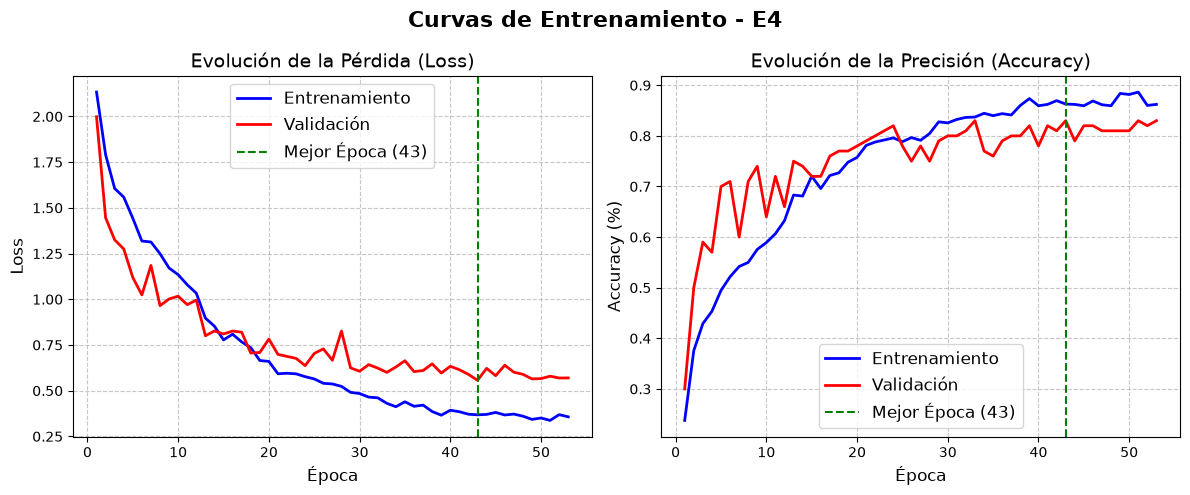

In [184]:
graficar_curvas(historial_e4, 'Curvas de Entrenamiento - E4')

En la primera gráfica, la pérdida desciende rápidamente durante las primeras 15 épocas. Luego, la curva de validación presenta fluctuaciones pero mantiene una tendencia a la baja hasta alcanzar su valor mínimo en la época 43, marcada con una línea vertical. Después de esa época, el error de validación deja de disminuir mientras que el de entrenamiento continúa bajando, lo que justifica la parada temprana para evitar que la red memorice los datos.

En la segunda gráfica, la precisión de validación se mantiene por encima del entrenamiento durante las primeras 25 épocas. Esto ocurre por el uso de la técnica de Dropout, que apaga conexiones durante el entrenamiento pero se desactiva al momento de validar. Pasada la época 30, el rendimiento de entrenamiento supera al de validación y sigue subiendo. La precisión de validación, en cambio, se estabiliza cerca del 83%, definiendo el punto óptimo del modelo en la época 43.


#### Matríz de Confusión

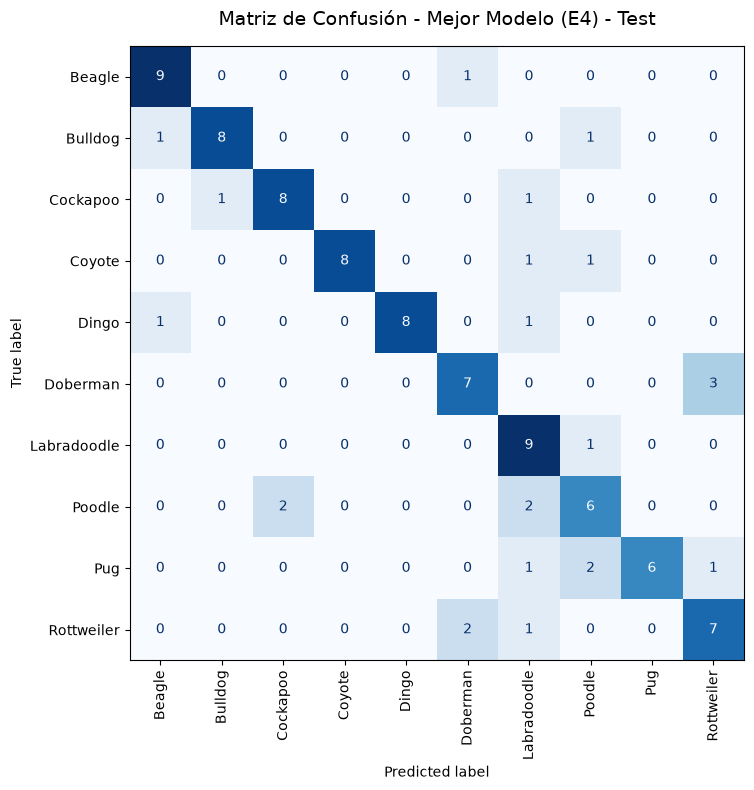

,precision,recall,f1-score,support
Beagle,0.82,0.90,0.86,10
Bulldog,0.89,0.80,0.84,10
Cockapoo,0.80,0.80,0.80,10
Coyote,1.00,0.80,0.89,10
Dingo,1.00,0.80,0.89,10
Doberman,0.70,0.70,0.70,10
Labradoodle,0.56,0.90,0.69,10
Poodle,0.55,0.60,0.57,10
Pug,1.00,0.60,0.75,10
Rottweiler,0.64,0.70,0.67,10


In [189]:
evaluar_cnn(
    modelo=modelo_e4,
    loader=test_loader,
    nombre="Mejor Modelo (E4) - Test",
    class_names=train_dataset.classes
)


El modelo logra una exactitud global del 76% (76 aciertos sobre 100 imágenes). Las clases muestran un rendimiento general equilibrado, destacándose Beagle y Labradoodle con la mayor cantidad de aciertos reales (recall de 0.90). Además, cuando el modelo predice las clases Coyote, Dingo o Pug, lo hace sin cometer errores (precisión de 1.00).

Al observar la matriz de confusión, los errores se concentran en razas con solapamiento visual:

**Textura del pelaje:** El Poodle registra el rendimiento más bajo (recall 0.60, precisión 0.55), ya que el modelo lo confunde con sus cruzas de pelo rizado (Cockapoo y Labradoodle). A su vez, Labradoodle concentra varios falsos positivos provenientes de otras razas.

**Color y anatomía:** Existe una confusión cruzada clara entre Doberman y Rottweiler (3 Dobermans clasificados como Rottweiler y 2 Rottweilers como Doberman), justificada por la distribución similar de colores oscuros en el pelaje de ambas razas.


#### Análisis Morfológico de Aciertos y Errores

El análisis visual de las clasificaciones incorrectas confirma que los fallos del modelo se originan en solapamientos morfológicos reales, encuadres atípicos o artefactos de iluminación. En casos como Cockapoo clasificado como Labradoodle, la textura ondulada del pelaje y la estructura facial son prácticamente indistinguibles a simple vista, justificando la confusión entre razas derivadas del caniche. Asimismo, en ejemplares con patrones de color inusuales o planos cerrados como el Bulldog blanco y negro confundido con Beagle por la franja blanca en el rostro, o el Beagle en sombra asignado a Doberman por tonos oscuros dominantes, la red prioriza la distribución de color o la textura local por sobre la estructura anatómica completa.


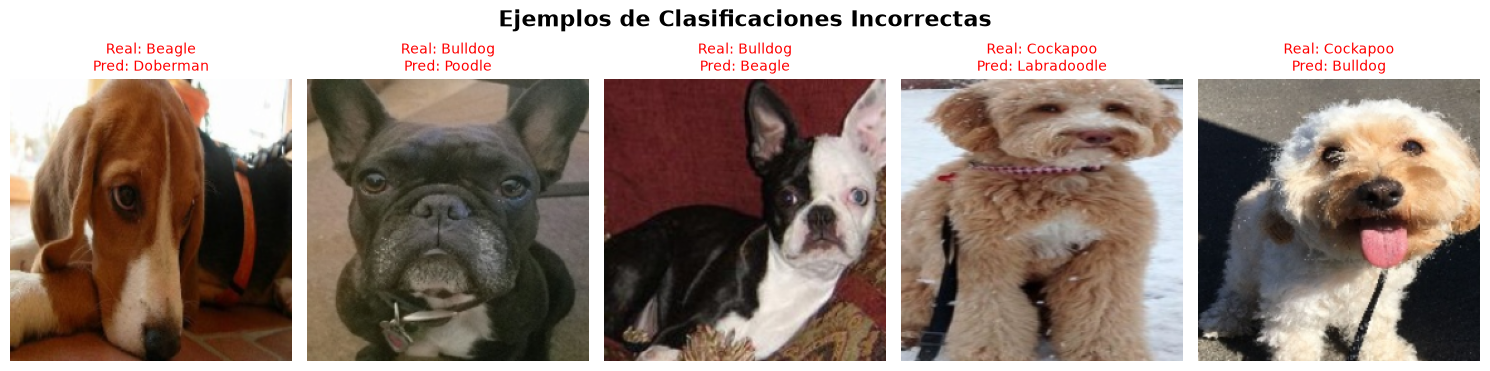

In [190]:
graficar_etiquetado_incorrecto(modelo_e4, test_loader, train_dataset.classes, DEVICE, 5)

La visualización de clasificaciones correctas muestra que el modelo identifica con precisión los rasgos más prominentes de las razas cuando las imágenes presentan buena iluminación y encuadres representativos. En los aciertos correspondientes a Beagle, la red reconoce con éxito la combinación de orejas caídas y redondeadas, la mancha blanca característica en el hocico y la frente, y el patrón de coloración tricolor o castaño con blanco, demostrando que extrae de forma robusta la estructura facial típica de la raza a pesar de variaciones leves en la postura o la expresión del animal.


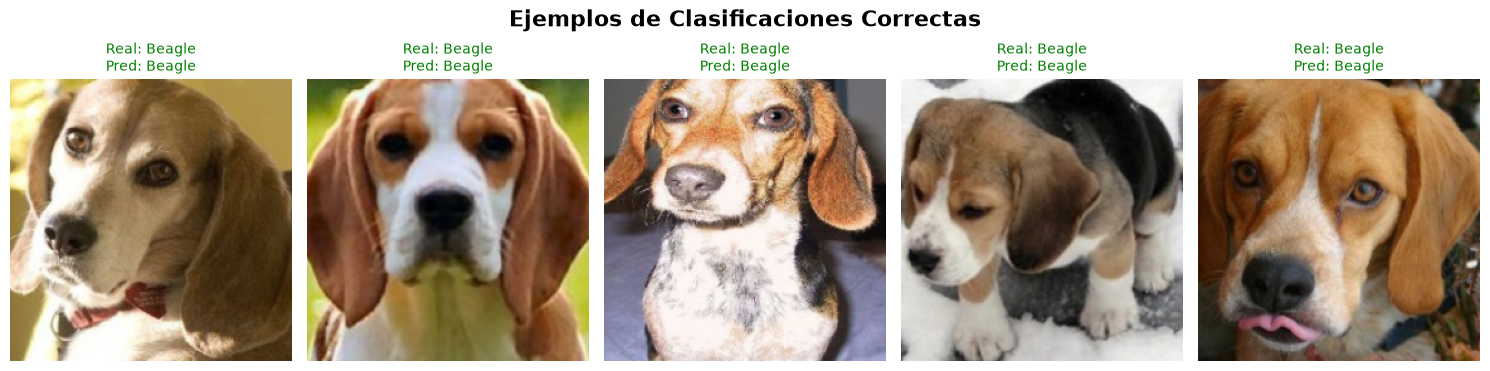

In [191]:
graficar_etiquetado_correcto(modelo_e4, test_loader, train_dataset.classes, DEVICE, 5)

## Anexo - Variación sobre E4

Como técnica complementaria de optimización se incorpora la inicialización de pesos de Kaiming (He Normal). Dado que la arquitectura emplea funciones de activación ReLU a lo largo de todas sus etapas, este método escala la varianza de los pesos iniciales en función de la cantidad de conexiones de entrada y salida de cada capa, compensando la anulación de señales negativas inherente a ReLU. De esta manera se preserva la magnitud de la varianza tanto en la propagación hacia adelante como en la retropropagación de gradientes, previniendo la atenuación temprana de la señal y favoreciendo una convergencia inicial más estable.


### E4 - Regularización + Kaiming

#### Implementación

In [194]:
class CNN_E4_Kaiming(nn.Module):
    """
    Fase E4 - Regularización y Optimización Avanzada.
    
    Características:
      - Arquitectura modular: Stem inicial + Inception multiescala + Bloques Residuales.
      - Batch Normalization en todas las convoluciones para estabilizar activaciones.
      - Inicialización de pesos Kaiming Normal (He) adaptada a funciones ReLU.
      - Dropout (p=0.5) en la cabeza clasificadora densa para mitigar co-adaptación.
    """
    def __init__(self, num_classes: int = 10, in_channels: int = 3, dropout_rate: float = 0.5):
        super().__init__()

        # --- STEM INICIAL (3 -> 32 -> 64 canales) ---
        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)  # (224 -> 112)
        )

        # --- ETAPA INCEPTION MULTIESCALA ---
        self.inception = ModuloInception(
            in_channels=64,
            out_1x1=32,
            red_3x3=32,
            out_3x3=48,
            red_5x5=16,
            out_5x5=32,
            out_pool=16
        )
        self.pool_inception = nn.MaxPool2d(kernel_size=2, stride=2)  # (112 -> 56)

        # --- ETAPA RESIDUAL ---
        self.res_bloque1 = BloqueResidual(in_channels=128, out_channels=128, stride=1)
        self.res_bloque2 = BloqueResidual(in_channels=128, out_channels=256, stride=2)  # (56 -> 28)

        # --- POOLING ADAPTATIVO ---
        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))

        # --- CABEZA CLASIFICADORA REGULARIZADA CON DROPOUT ---
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_rate),
            nn.Linear(256, num_classes)
        )

        # --- APLICACIÓN DE INICIALIZACIÓN KAIMING ---
        self._inicializar_pesos_kaiming()

    def _inicializar_pesos_kaiming(self):
        """
        Recorre todos los módulos de la red aplicando Kaiming Normal a capas
        lineales y convolucionales, y fijando BatchNorm con escala 1 y sesgo 0.
        """
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.Linear)):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0.0)
            elif isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):
                nn.init.constant_(m.weight, 1.0)
                nn.init.constant_(m.bias, 0.0)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.stem(x)
        x = self.inception(x)
        x = self.pool_inception(x)
        x = self.res_bloque1(x)
        x = self.res_bloque2(x)
        x = self.adaptive_pool(x)
        logits = self.classifier(x)
        return logits


#### Entrenamiento de E4 + Kaiming

In [195]:
# Fijar semilla previa a la inicialización
fijar_semilla(SEMILLA)

num_clases = len(train_dataset.classes)
modelo_e4_kaiming = CNN_E4_Kaiming(num_classes=num_clases, in_channels=3, dropout_rate=0.5).to(DEVICE)

# Conteo y comparativa de parámetros
total_params_e4_kaiming = sum(p.numel() for p in modelo_e4_kaiming.parameters())
trainable_params_e4_kaiming = sum(p.numel() for p in modelo_e4_kaiming.parameters() if p.requires_grad)

print(f"Modelo E4 instanciado en: {DEVICE} (Pesos inicializados con Kaiming Normal)")
print(f"Total de parámetros E4: {total_params_e4_kaiming:,}")
print(f"Diferencia respecto a E1: {trainable_params_e4_kaiming - total_params:+,} parámetros\n")

# Recrear el DataLoader aumentado con batch_size=64 para acelerar en CPU
train_loader_aug_rapido = DataLoader(
    train_dataset_balanceado,
    batch_size=64,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

# Optimizador con regularización L2
criterio_e4 = nn.CrossEntropyLoss()
optimizador_e4 = torch.optim.Adam(modelo_e4.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_e4 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizador_e4, mode='min', factor=0.5, patience=2
)

# Entrenamiento de E4 + Kaiming
historial_e4_kaiming, modelo_e4_kaiming = entrenar_modelo(
    modelo=modelo_e4,
    loader_train=train_loader_aug_rapido,
    loader_val=valid_loader,
    criterio=criterio_e4,
    optimizador=optimizador_e4,
    scheduler=scheduler_e4,
    epochs=100,
    patience=10,
    device=DEVICE,
    nombre="E4 - Regularización (Kaiming + Dropout + Aug + L2)",
    checkpoint_path="checkpoints_ej3/e4_regularizada_kaiming.pth"
)

Modelo E4 instanciado en: cpu (Pesos inicializados con Kaiming Normal)
Total de parámetros E4: 2,318,474
Diferencia respecto a E1: +1,697,888 parámetros

 Iniciando entrenamiento de: E4 - Regularización (Kaiming + Dropout + Aug + L2)
 Dispositivo: cpu | Épocas: 1 a 100 | Patience: 10
 Criterio: CrossEntropyLoss | Optimizador: Adam
 Scheduler: ReduceLROnPlateau
 Archivo de Checkpoint: checkpoints_ej3/e4_regularizada_kaiming.pth


KeyboardInterrupt: 

#### Métricas de E4 + Kaiming

In [ ]:
acc_train_e4_kaiming = float(evaluar_accuracy_cnn(modelo_e4_kaiming, train_loader, DEVICE))
acc_val_e4_kaiming   = float(evaluar_accuracy_cnn(modelo_e4_kaiming, valid_loader, DEVICE))
acc_test_e4_kaiming  = float(evaluar_accuracy_cnn(modelo_e4_kaiming, test_loader, DEVICE))

print("=" * 60)
print(" RESUMEN DE RENDIMIENTO - E4 (REGULARIZACIÓN Y KAIMING)")
print("=" * 60)
print(f" Precisión en Train: {acc_train_e4_kaiming * 100:6.2f}% (E1: {acc_train_e1 * 100:6.2f}% | E2: {acc_train_e2 * 100:6.2f}% | E3: {acc_train_e3 * 100:6.2f}%) | E4: {acc_train_e4 * 100:6.2f}%)")
print(f" Precisión en Valid: {acc_val_e4_kaiming * 100:6.2f}% (E1: {acc_val_e1 * 100:6.2f}% | E2: {acc_val_e2 * 100:6.2f}% | E3: {acc_val_e3 * 100:6.2f}%) | E4: {acc_train_e4 * 100:6.2f}%)")
print(f" Precisión en Test:  {acc_test_e4_kaiming * 100:6.2f}% (E1: {acc_test_e1 * 100:6.2f}% | E2: {acc_test_e2 * 100:6.2f}% | E3: {acc_test_e3 * 100:6.2f}% | E4: {acc_train_e4 * 100:6.2f}%))")
print("=" * 60)